In [1]:
from Utils.Draw_nn import draw_dot
from Value import Value
from MLP import MLP
import torch
import torch.nn as nn
import torch.optim as optim


**Value Class demo**

In [2]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.Tanh()

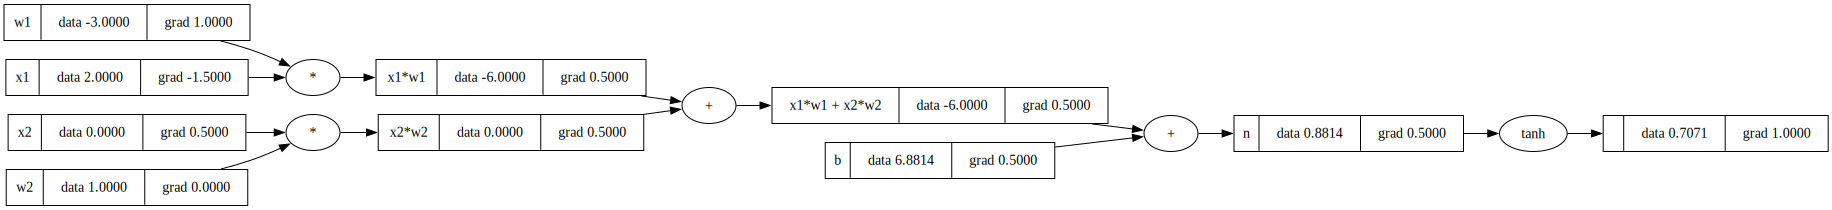

In [3]:
o.backward()
draw_dot(o)

**Compare with torch**

In [4]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [5]:
print(o)
print(x2.grad)
w1.grad.item()

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)
tensor([0.5000], dtype=torch.float64)


1.0000002567688737

**How to use implemented MLP**

In [6]:
X = [2.0,3.0,-1.0]
mlp = MLP()
mlp.Linear(3,4)
mlp.Linear(4,4)
mlp.Linear(4,1)
out = mlp(X) #Feed Forward
out

Data: -0.6418737001846508

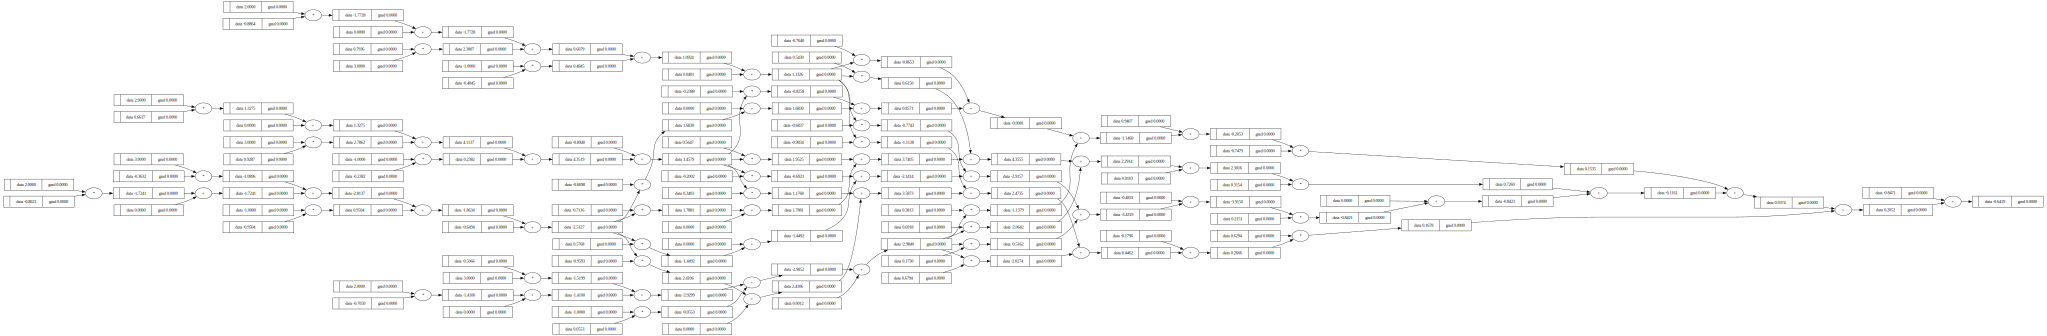

In [7]:
draw_dot(out)

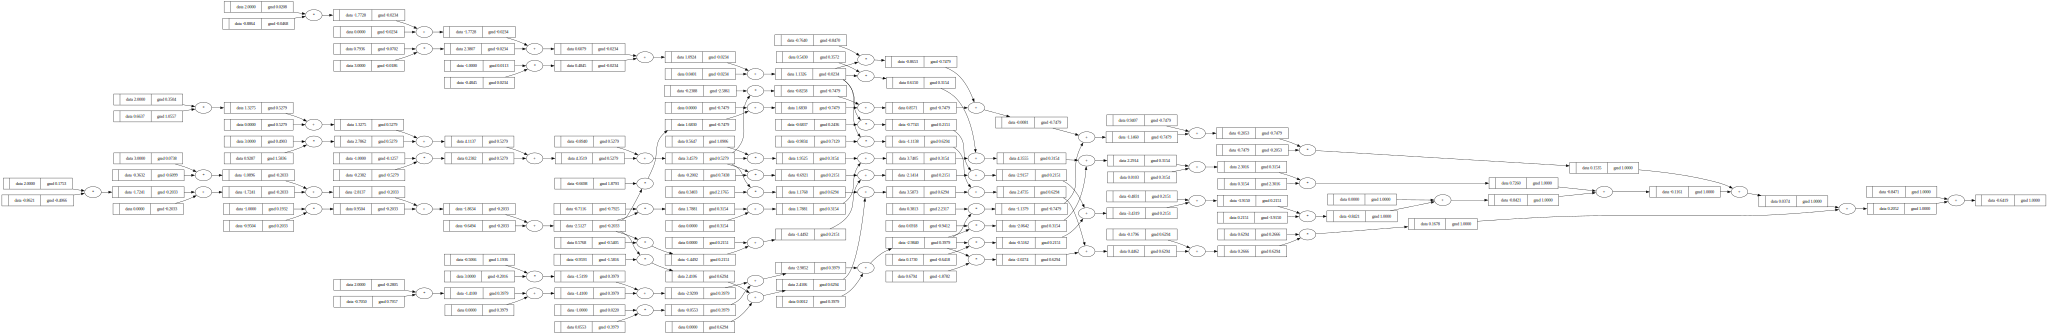

In [8]:
out.backward()
draw_dot(out)

**Example showing how it learn**

In [9]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [10]:
mlp = MLP()
mlp.Linear(3,4)
mlp.Tanh()
mlp.Linear(4,4)
mlp.Tanh()
mlp.Linear(4,1)

In [11]:
for i in range(20):
    #Feed Forward
    out = [mlp(x) for x in xs]

    mlp.zero_grad()
    loss = sum(((y_gd - y_pred)**2 for y_gd,y_pred in zip(ys,out)))

    
    loss.backward()
    mlp.step(lr = 0.01)
    
    print(f"Loss: {loss}")
loss

Loss: Data: 5.947567461539675
Loss: Data: 4.319774763686977
Loss: Data: 3.6214713720514773
Loss: Data: 3.2351010111022154
Loss: Data: 2.9527658989801555
Loss: Data: 2.701342104957046
Loss: Data: 2.453773298315239
Loss: Data: 2.202504912760097
Loss: Data: 1.9512431913698567
Loss: Data: 1.7089256732064562
Loss: Data: 1.4835731288696263
Loss: Data: 1.2796140517182337
Loss: Data: 1.0984588025754543
Loss: Data: 0.9396958745198095
Loss: Data: 0.8019191361793301
Loss: Data: 0.6832303064822275
Loss: Data: 0.5815467772778841
Loss: Data: 0.49478838442750883
Loss: Data: 0.420985746607735
Loss: Data: 0.35833744938973955


Data: 0.35833744938973955

In [12]:
out

[Data: 0.7638317185027718,
 Data: -0.5424581635190825,
 Data: -0.8433663988294938,
 Data: 0.7379248675314393]

**Compare Results with Torch MLP**

In [13]:
# 1. Convert your lists to PyTorch Tensors
xs = torch.tensor(xs, dtype=torch.float32)
ys = torch.tensor(ys, dtype=torch.float32).view(-1,1)

model = nn.Sequential(
    nn.Linear(3, 4),
    nn.Tanh(), 
    nn.Linear(4, 4),
    nn.Tanh(),
    nn.Linear(4, 1)
)

# reduction='sum' matches `sum((y_gd - y_pred)**2)` logic
criterion = nn.MSELoss(reduction='sum')

optimizer = optim.SGD(model.parameters(), lr=0.01)

# 4. Training Loop
for i in range(20):
    #Feed Forward
    out = model(xs)
    
    # Calculate loss
    loss = criterion(out, ys)
    
    # Zero gradients, perform backward pass, and update weights
    optimizer.zero_grad()  # Equivalent to loss.zero_grad()
    loss.backward()        # Equivalent to loss.backward()
    optimizer.step()       # Equivalent to loss.update()

print(f"Final Loss: {loss.item():.4f}") 

print("Final Predictions:")
print(out.detach())

Final Loss: 2.5572
Final Predictions:
tensor([[ 0.2003],
        [-0.1360],
        [-0.2404],
        [ 0.2292]])
